In [151]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, make_scorer   
from sklearn.model_selection import GridSearchCV
from tabulate import tabulate
warnings.filterwarnings('ignore')

In [152]:
train=pd.read_csv(r"Train_data.csv")
test=pd.read_csv(r"Test_data.csv")
train

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,tcp,exec,RSTO,0,0,0,0,0,0,...,7,0.03,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
25188,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,39,1.00,0.00,1.00,0.18,0.00,0.00,0.00,0.00,anomaly
25189,0,tcp,private,REJ,0,0,0,0,0,0,...,13,0.05,0.07,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
25190,0,tcp,nnsp,S0,0,0,0,0,0,0,...,20,0.08,0.06,0.00,0.00,1.00,1.00,0.00,0.00,anomaly


In [153]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [154]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [155]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [156]:
train.describe(include='object')

,protocol_type,service,flag,class
count,25192,25192,25192,25192
unique,3,66,11,2
top,tcp,http,SF,normal
freq,20526,8003,14973,13449


In [157]:
total = train.shape[0]
missing_columns = [col for col in train.columns if train[col].isnull().sum() > 0]
for col in missing_columns:
    null_count = train[col].isnull().sum()
    per = (null_count/total) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")

In [158]:
print(f"Number of duplicate rows: {train.duplicated().sum()}")

Number of duplicate rows: 0


<Axes: xlabel='class', ylabel='count'>

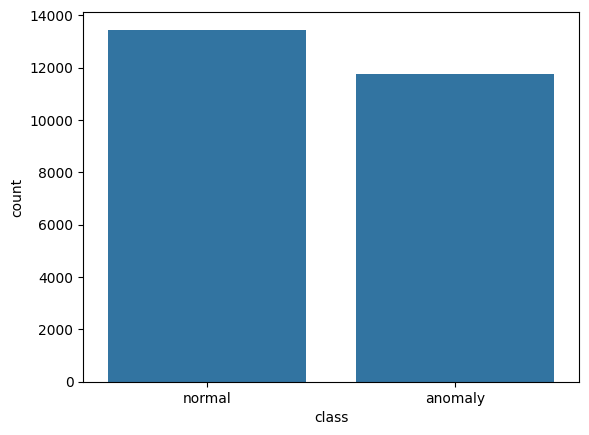

In [159]:
sns.countplot(x=train['class'])

In [160]:
cat_features = ['protocol_type', 'service', 'flag']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
train[cat_features] = encoder.fit_transform(train[cat_features])
test[cat_features] = encoder.transform(test[cat_features])

train['class'] = train['class'].astype('category').cat.codes

In [161]:
train.drop(['num_outbound_cmds'], axis=1, inplace=True)
test.drop(['num_outbound_cmds'], axis=1, inplace=True)
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,1.0,19.0,9.0,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,0,2.0,41.0,9.0,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,0,1.0,46.0,5.0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,1.0,22.0,9.0,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,0,1.0,22.0,9.0,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


<Axes: >

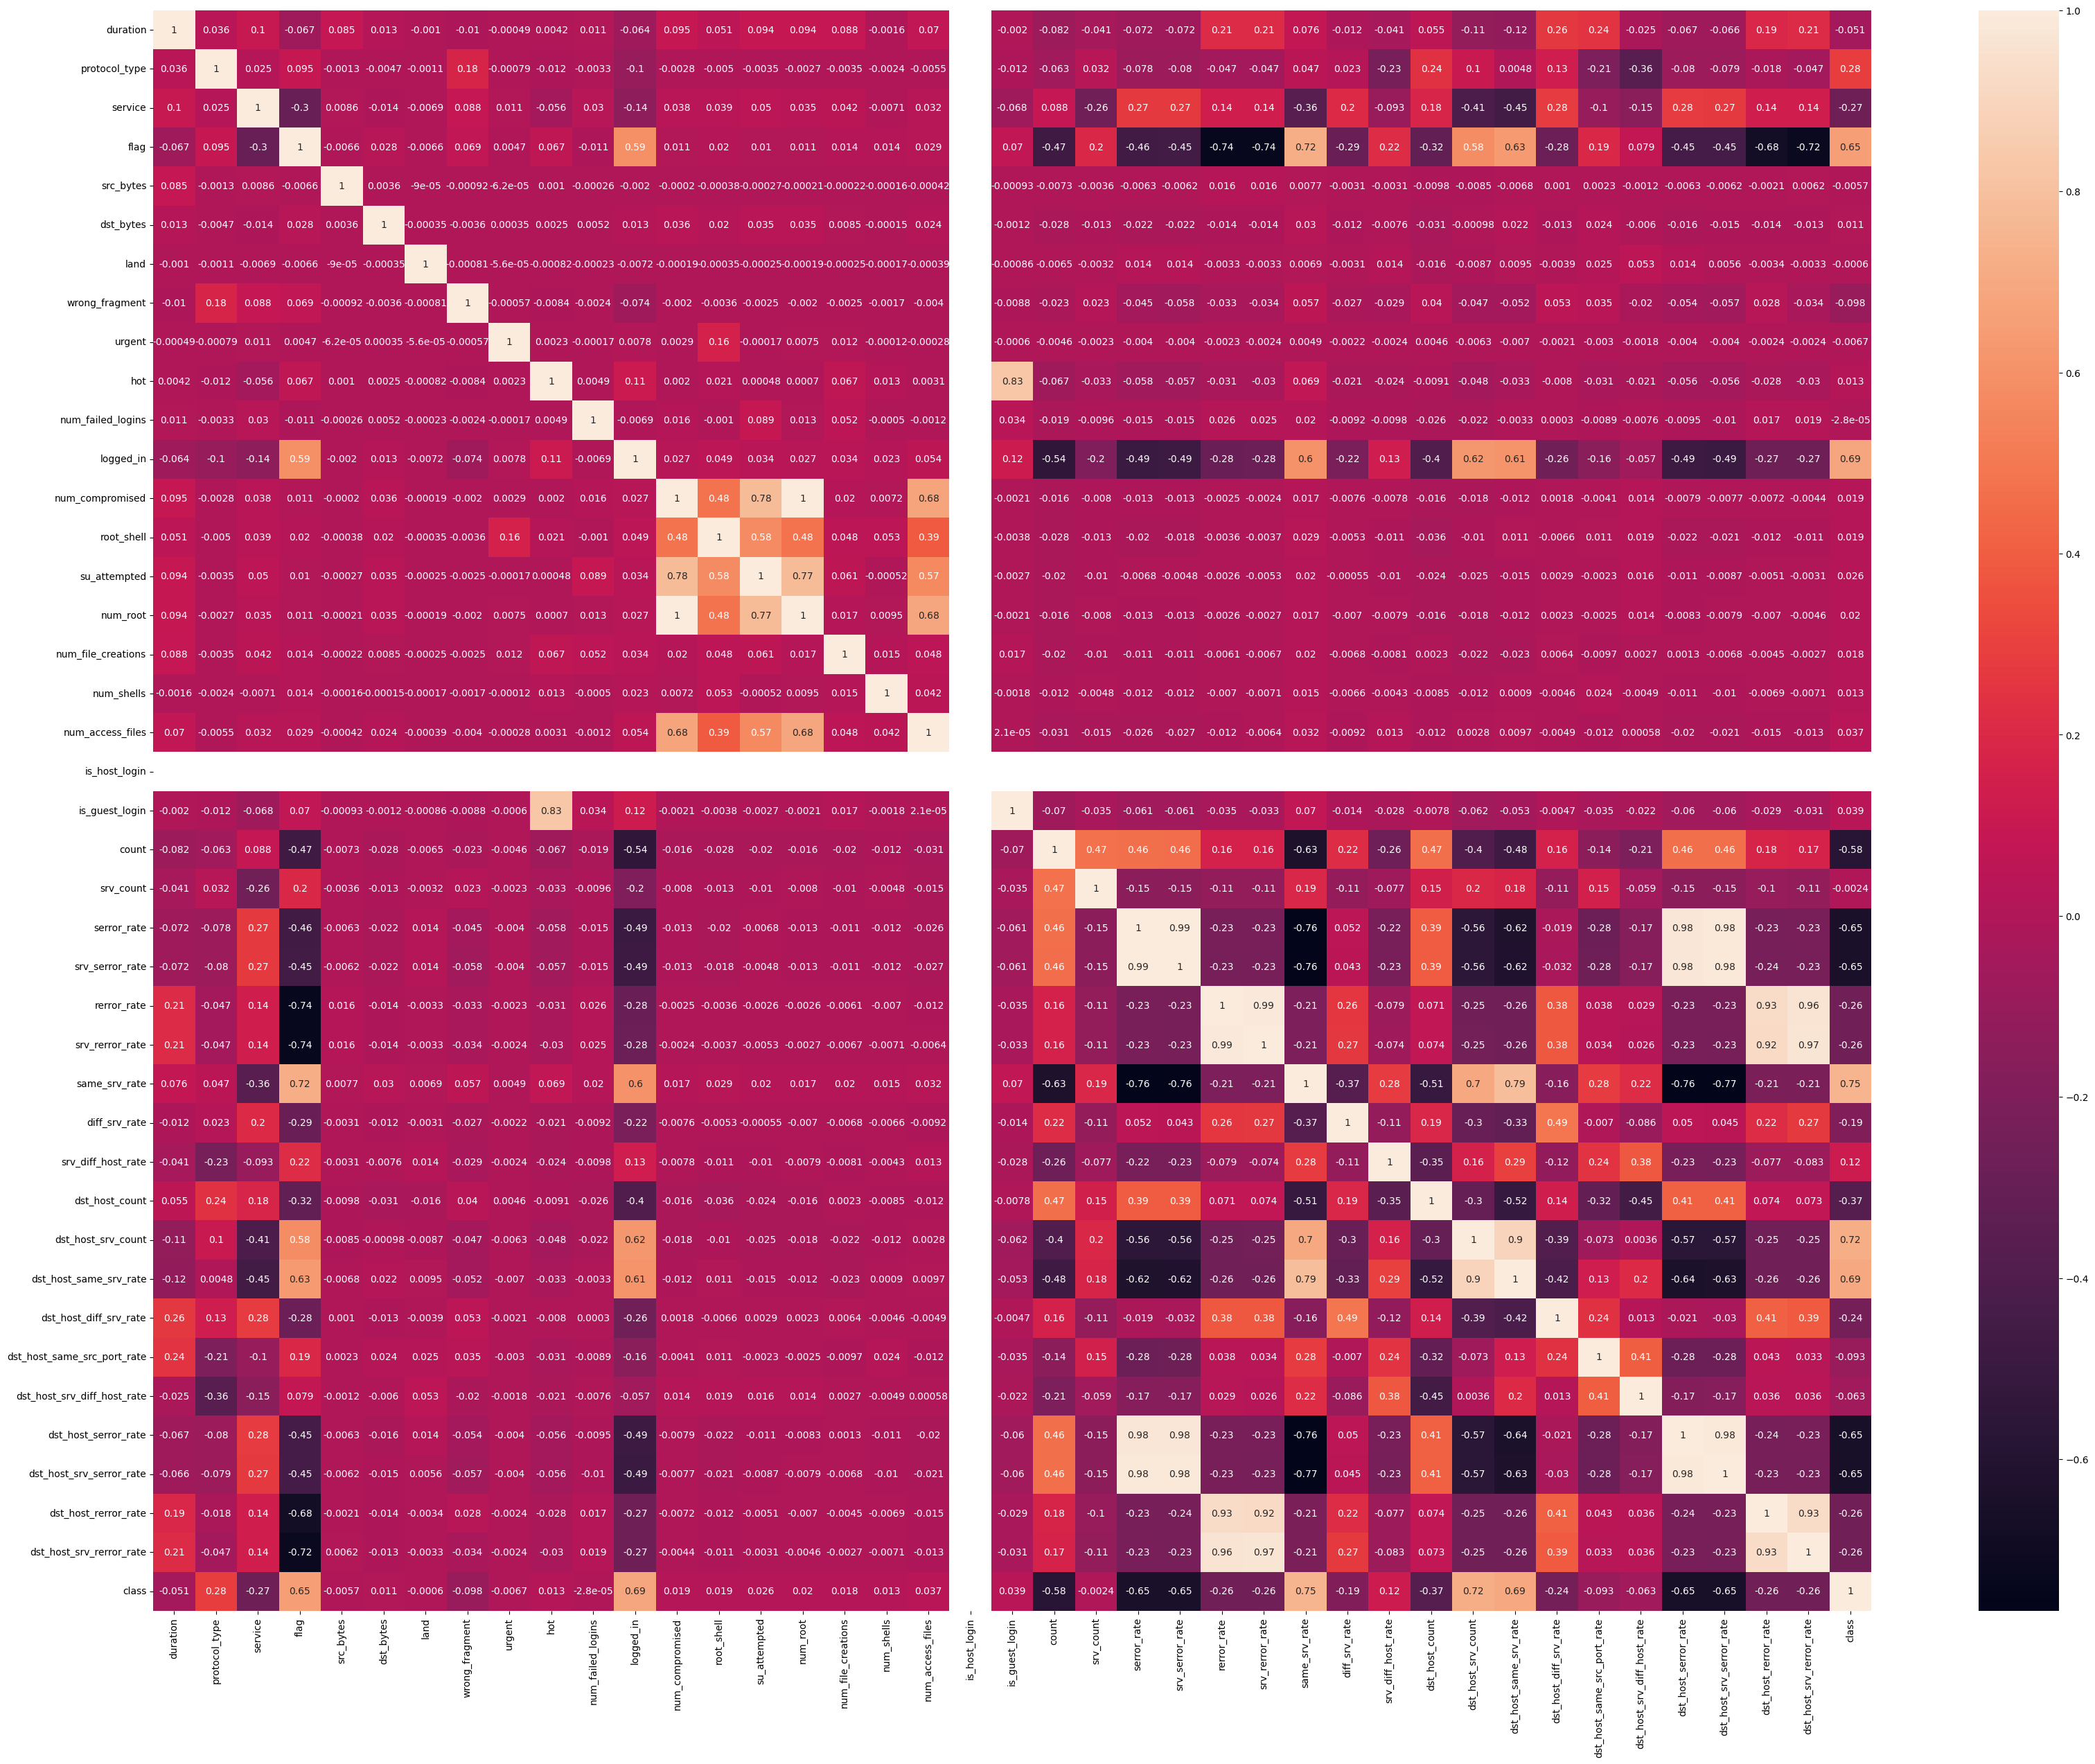

In [162]:
plt.figure(figsize=(40,30))
sns.heatmap(train.corr(), annot=True)

In [163]:
X = train.drop(['class'], axis=1)
Y = train['class']

In [164]:
test

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1.0,46.0,1.0,0,0,0,0,0,0,...,255,10,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00
1,0,1.0,46.0,1.0,0,0,0,0,0,0,...,255,1,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00
2,2,1.0,19.0,9.0,12983,0,0,0,0,0,...,134,86,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00
3,0,0.0,13.0,9.0,20,0,0,0,0,0,...,3,57,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00
4,1,1.0,57.0,2.0,0,15,0,0,0,0,...,29,86,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,1.0,51.0,9.0,794,333,0,0,0,0,...,100,141,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00
22540,0,1.0,22.0,9.0,317,938,0,0,0,0,...,197,255,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00
22541,0,1.0,22.0,9.0,54540,8314,0,0,0,2,...,255,255,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07
22542,0,2.0,11.0,9.0,42,42,0,0,0,0,...,255,252,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00


In [165]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.70, random_state=2)

In [166]:
lg_model = LogisticRegression(random_state=42)
lg_model.fit(x_train, y_train)

f1_eval = make_scorer(f1_score)

y_train_pred = lg_model.predict(x_train)
y_test_pred = lg_model.predict(x_test)

lg_train_accuracy = accuracy_score(y_train, y_train_pred)
lg_train_f1 = f1_score(y_train, y_train_pred).round(2)

lg_test_accuracy = accuracy_score(y_test, y_test_pred)
lg_test_f1 = f1_score(y_test, y_test_pred)

print(f"Training Accuracy: {lg_train_accuracy:.4f}")
print(f"Training F1 Score: {lg_train_f1:.4f}")

print(f"Test Accuracy: {lg_test_accuracy:.4f}")
print(f"Test F1 Score: {lg_test_f1:.4f}")

cvscore1 = cross_val_score(lg_model, X, Y, cv=5, scoring=f1_eval).mean()
print(f"CV F1 Score: {cvscore1:.4f}")

Training Accuracy: 0.8786
Training F1 Score: 0.8900
Test Accuracy: 0.8715
Test F1 Score: 0.8805
CV F1 Score: 0.8850


In [167]:
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

f1_eval = make_scorer(f1_score)

y_train_pred = rf.predict(x_train)
y_test_pred = rf.predict(x_test)

rf_train_accuracy = accuracy_score(y_train, y_train_pred)
rf_train_f1 = f1_score(y_train, y_train_pred).round(2)

rf_test_accuracy = accuracy_score(y_test, y_test_pred)
rf_test_f1 = f1_score(y_test, y_test_pred)

print(f"Training Accuracy: {rf_train_accuracy:.4f}")
print(f"Training F1 Score: {rf_train_f1:.4f}")

print(f"Test Accuracy: {rf_test_accuracy:.4f}")
print(f"Test F1 Score: {rf_test_f1:.4f}")

cvscore2 = cross_val_score(rf, X, Y, cv=5, scoring=f1_eval).mean()
print(f"CV F1 Score: {cvscore2:.4f}")

Training Accuracy: 1.0000
Training F1 Score: 1.0000
Test Accuracy: 0.9970
Test F1 Score: 0.9972
CV F1 Score: 0.9973


In [168]:
xgb_model = XGBClassifier(objective="binary:logistic", random_state=42)
xgb_model.fit(x_train, y_train)

f1_eval = make_scorer(f1_score)

y_train_pred = xgb_model.predict(x_train)
y_test_pred = xgb_model.predict(x_test)

xgb_train_accuracy = accuracy_score(y_train, y_train_pred)
xgb_train_f1 = f1_score(y_train, y_train_pred).round(2)

xgb_test_accuracy = accuracy_score(y_test, y_test_pred)
xgb_test_f1 = f1_score(y_test, y_test_pred)

print(f"Training Accuracy: {xgb_train_accuracy:.4f}")
print(f"Training F1 Score: {xgb_train_f1:.4f}")

print(f"Test Accuracy: {xgb_test_accuracy:.4f}")
print(f"Test F1 Score: {xgb_test_f1:.4f}")

cvscore3 = cross_val_score(xgb_model, X, Y, cv=5, scoring=f1_eval).mean()
print(f"CV F1 Score: {cvscore3:.4f}")

Training Accuracy: 1.0000
Training F1 Score: 1.0000
Test Accuracy: 0.9970
Test F1 Score: 0.9972
CV F1 Score: 0.9978


In [169]:
data = [["Logistic Regression", lg_train_accuracy, lg_test_accuracy,cvscore1],
        ["Random Forest", rf_train_accuracy, rf_test_accuracy,cvscore2],
        ["XGBM", xgb_train_accuracy, xgb_test_accuracy,cvscore3],
        ]
col_names = ["Model", "Train Score", "Test Score","CV Score"]
print(tabulate(data, headers=col_names, tablefmt="fancy_grid"))

╒═════════════════════╤═══════════════╤══════════════╤════════════╕
│ Model               │   Train Score │   Test Score │   CV Score │
╞═════════════════════╪═══════════════╪══════════════╪════════════╡
│ Logistic Regression │      0.878587 │     0.871527 │   0.885017 │
├─────────────────────┼───────────────┼──────────────┼────────────┤
│ Random Forest       │      1        │     0.996957 │   0.997327 │
├─────────────────────┼───────────────┼──────────────┼────────────┤
│ XGBM                │      1        │     0.996957 │   0.997808 │
╘═════════════════════╧═══════════════╧══════════════╧════════════╛


In [170]:
params = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [10, 20, 50]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(x_train, y_train)

best_params = grid.best_params_

In [171]:
best_model = grid.best_estimator_
feature_importances = best_model.feature_importances_

In [172]:
feats=pd.DataFrame(data=grid.best_estimator_.feature_importances_,index=X.columns,columns=['Importance'])
feats

,Importance
duration,0.002989
protocol_type,0.036228
service,0.019175
flag,0.093672
src_bytes,0.161586
dst_bytes,0.162346
land,0.000000
wrong_fragment,0.002959
urgent,0.000000
hot,0.010769


In [181]:
important_features=feats[feats['Importance']>0.05]
important_features

,Importance
flag,0.093672
src_bytes,0.161586
dst_bytes,0.162346
same_srv_rate,0.078822
dst_host_same_srv_rate,0.050027


In [182]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.70, random_state=2)

In [183]:
finalmodel=RandomForestClassifier(random_state=42)
finalmodel.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [184]:
finalmodel_accuracy = accuracy_score(y_test, finalmodel.predict(x_test))
finalmodel_f1 = f1_score(y_test, finalmodel.predict(x_test))
print(f"Final Model Accuracy: {finalmodel_accuracy:.4f}")
print(f"Final Model F1 Score: {finalmodel_f1:.4f}")

Final Model Accuracy: 0.9970
Final Model F1 Score: 0.9972


In [185]:
specific_row = test.iloc[0:1,:] 
print(specific_row)

   duration  protocol_type  service  flag  src_bytes  dst_bytes  land  \
0         0            1.0     46.0   1.0          0          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_count  dst_host_srv_count  \
0               0       0    0  ...             255                  10   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.04                    0.06   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0                          0.0                          0.0   

   dst_host_serror_rate  dst_host_srv_serror_rate  dst_host_rerror_rate  \
0                   0.0                       0.0                   1.0   

   dst_host_srv_rerror_rate  
0                       1.0  

[1 rows x 40 columns]


In [186]:
new_data=specific_row

In [187]:
result=finalmodel.predict(new_data)
print(result)
if result==1:
    print('Normal')
else:
    print('Anamoly')

[0]
Anamoly


In [180]:
from pickle import dump
dump(finalmodel,open('breachmodel.pkl','wb'))